In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Configuración estética profesional para las visualizaciones
sns.set_theme(style="whitegrid")

# 1. Carga del dataset procesado
# Utilizamos parse_dates para que Pandas interprete la columna temporal correctamente
df = pd.read_csv('../data/processed/streaming_users_clean.csv', parse_dates=['last_login_date'])

# 2. Verificación de la importación
print("Estructura del Dataset:")
df.info()

# 3. Inspección visual de los primeros registros
display(df.head())

Estructura del Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   user_id                   8000 non-null   int64         
 1   age                       8000 non-null   int64         
 2   subscription_plan         8000 non-null   str           
 3   monthly_watch_time_mins   8000 non-null   float64       
 4   country                   8000 non-null   str           
 5   favorite_genre            8000 non-null   str           
 6   last_login_date           8000 non-null   datetime64[us]
 7   customer_support_tickets  8000 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(3)
memory usage: 669.4 KB


,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
0,10000,39,Estándar,805.8,Brasil,Crimen,2025-03-04,0.0
1,10001,37,Estándar,1173.4,Colombia,Crimen,2019-04-02,2.0
2,10002,28,Básico,401.0,Colombia,Crimen,2018-04-13,0.0
3,10003,43,Básico,62.4,Uruguay,Thriller,2021-01-31,0.0
4,10004,51,Básico,477.8,Perú,Thriller,2020-09-30,1.0


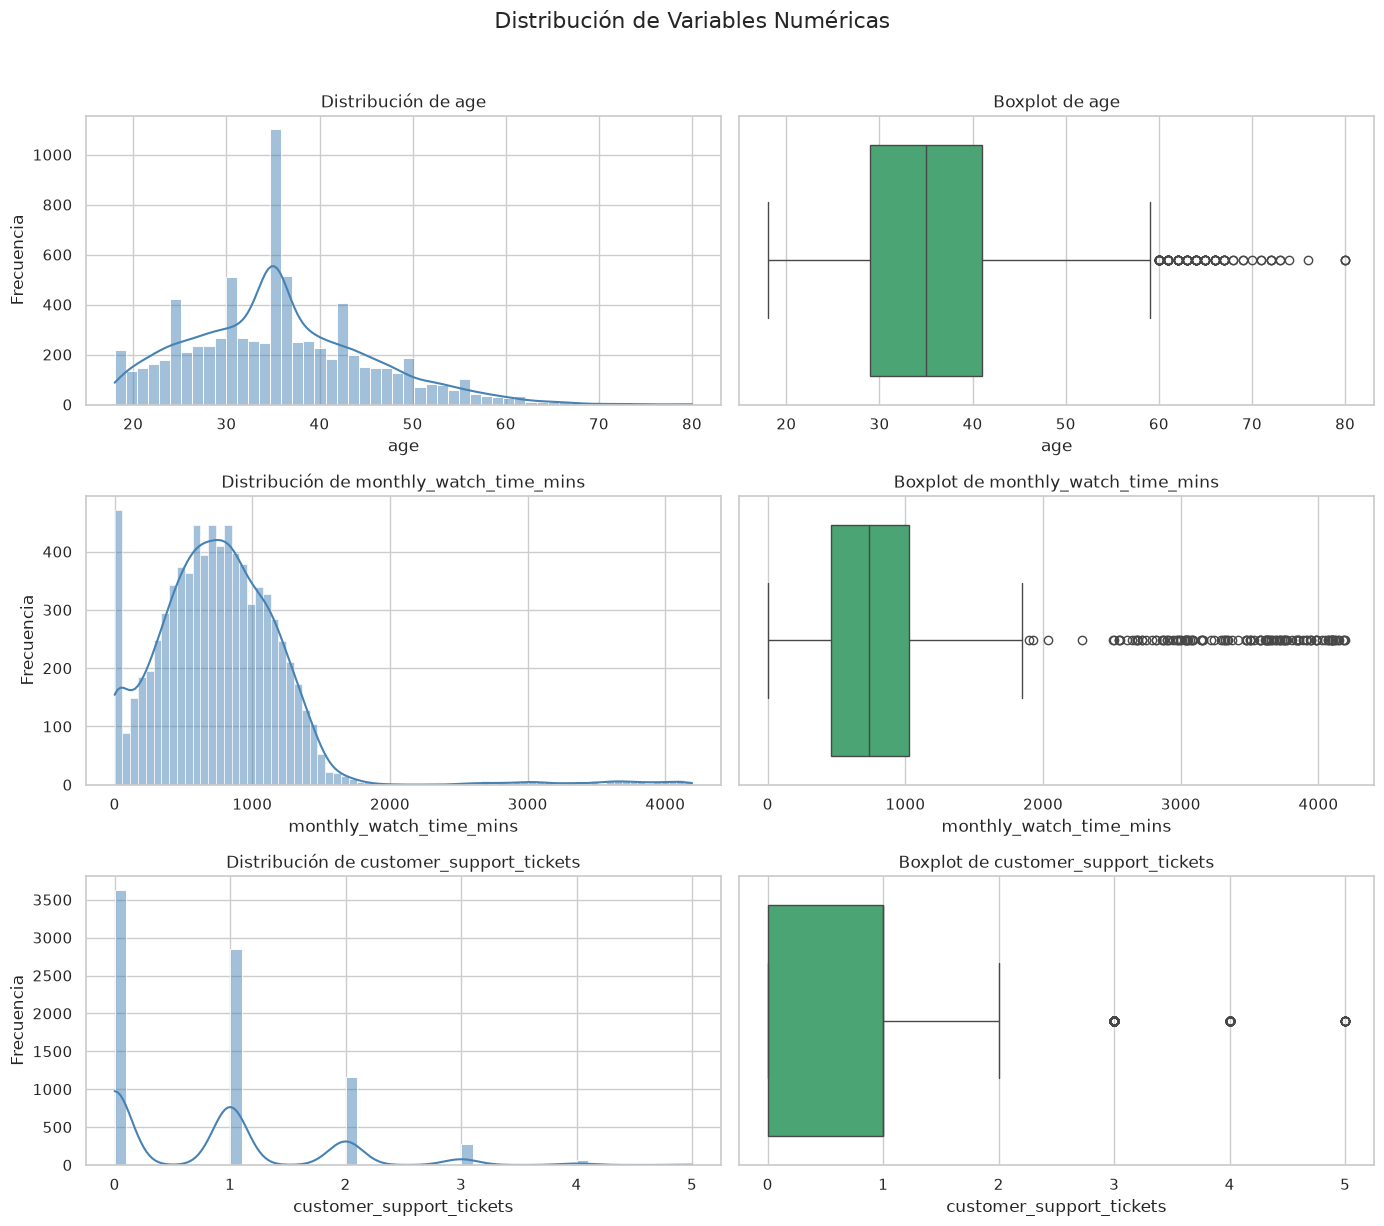

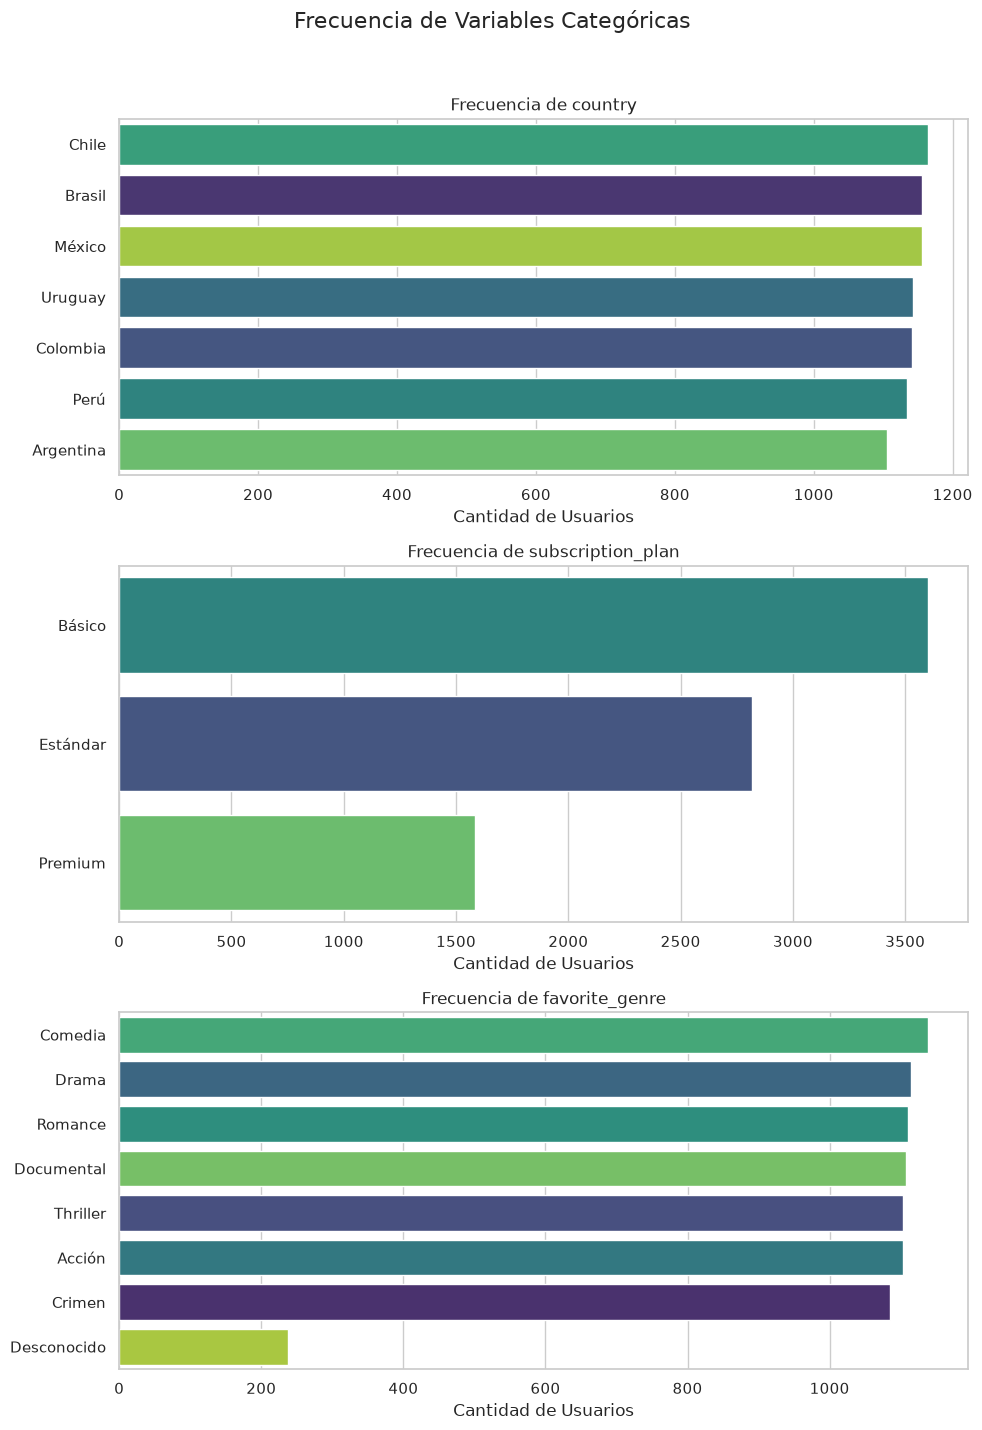

In [4]:
# 1. ANÁLISIS UNIVARIADO: VARIABLES NUMÉRICAS
columnas_numericas = ['age', 'monthly_watch_time_mins', 'customer_support_tickets']

# Creamos una figura con 3 filas y 2 columnas
fig, axes = plt.subplots(nrows=len(columnas_numericas), ncols=2, figsize=(14, 12))
fig.suptitle('Distribución de Variables Numéricas', fontsize=16, y=1.02)

for i, col in enumerate(columnas_numericas):
    # Histograma para ver la forma de la distribución
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='steelblue')
    axes[i, 0].set_title(f'Distribución de {col}')
    axes[i, 0].set_ylabel('Frecuencia')
    
    # Boxplot para evaluar la dispersión y confirmar la limpieza de outliers
    sns.boxplot(x=df[col], ax=axes[i, 1], color='mediumseagreen')
    axes[i, 1].set_title(f'Boxplot de {col}')

plt.tight_layout()
plt.show()

# 2. ANÁLISIS UNIVARIADO: VARIABLES CATEGÓRICAS
columnas_categoricas = ['country', 'subscription_plan', 'favorite_genre']

# Creamos una figura con 3 filas y 1 columna
fig, axes = plt.subplots(nrows=len(columnas_categoricas), ncols=1, figsize=(10, 14))
fig.suptitle('Frecuencia de Variables Categóricas', fontsize=16, y=1.02)

for i, col in enumerate(columnas_categoricas):
    # Countplot ordenado de mayor a menor frecuencia
    sns.countplot(
        data=df, 
        y=col, 
        ax=axes[i], 
        order=df[col].value_counts().index, 
        hue=col,
        legend=False,
        palette='viridis'
    )
    axes[i].set_title(f'Frecuencia de {col}')
    axes[i].set_xlabel('Cantidad de Usuarios')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

### Interpretación del Análisis Univariado

#### 1. Variables Numéricas
* **Edad (`age`):** La base de usuarios presenta una media de **35.6 años** (mediana de 35) y un rango intercuartílico (IQR) concentrado entre los **29 y 41 años** (con un rango general de 18 a 80). Desde el punto de vista del negocio, esto describe a un público adulto joven y de mediana edad en su etapa económicamente activa. Esto resulta clave para el diseño de campañas de marketing y la selección del catálogo, priorizando temáticas afines a este segmento de alto poder adquisitivo.
* **Tiempo de Visualización Mensual (`monthly_watch_time_mins`):** Muestra una distribución sesgada a la derecha con un promedio de **768.4 minutos** (~12.8 horas/mes) y una mediana de **737.1 minutos** (~12.3 horas/mes). Se detectan usuarios con consumos extremos que superan los **4,000 minutos mensuales** (~66 horas/mes). Para el negocio, este grupo de "superusuarios" representa el núcleo de retención y lealtad de la plataforma, mientras que la mediana refleja un hábito de consumo regular y saludable (unos 25 minutos diarios), lo cual indica una interacción sostenida pero no intensiva para el usuario promedio.
* **Tickets de Soporte (`customer_support_tickets`):** La distribución está fuertemente concentrada en valores bajos, con una media de **0.79 tickets** por usuario y un tercer cuartil (75%) de solo **1 ticket** (máximo de 5). Esto indica que la **carga operativa de soporte técnico es baja y manejable** para la inmensa mayoría de los usuarios, sugiriendo estabilidad en la infraestructura de la plataforma y en los procesos de facturación. Los casos extremos (4 o 5 tickets) son anomalías puntuales que no saturan el sistema de atención.

#### 2. Variables Categóricas
* **Distribución Geográfica (`country`):** Existe una equidad notable en la distribución de usuarios en América Latina, donde cada país oscila de manera uniforme entre el **13.8% (Argentina)** y el **14.5% (Chile)**. Esta diversificación geográfica mitiga el riesgo sistémico de depender de un solo mercado local. No obstante, plantea el reto operativo de mantener una estrategia de distribución de contenido (CDN) y un portafolio de licencias homogéneo y localizado a nivel regional.
* **Planes de Suscripción (`subscription_plan`):** El **45%** de los usuarios se encuentra en el plan **Básico**, el **35.2%** en el **Estándar** y el **19.8%** en el **Premium**. Esta estructura piramidal es habitual en modelos de suscripción, pero revela una gran oportunidad de negocio: casi la mitad de la base de datos está monetizada al menor nivel posible. Existe un espacio significativo para campañas de *upselling* enfocadas en migrar a usuarios del plan Básico al Estándar o Premium mediante la promoción de beneficios específicos (como resolución 4K o pantallas simultáneas).
* **Preferencias de Contenido (`favorite_genre`):** Exceptuando un **2.96%** catalogado como "Desconocido", los géneros favoritos están prácticamente empatados entre el **13.5% (Crimen)** y el **14.2% (Comedia)**. Esta homogeneidad en las preferencias del usuario demuestra que la plataforma no se sostiene sobre un género de nicho, sino que requiere una biblioteca horizontal, diversa y equilibrada para sostener el enganche de sus diferentes públicos.

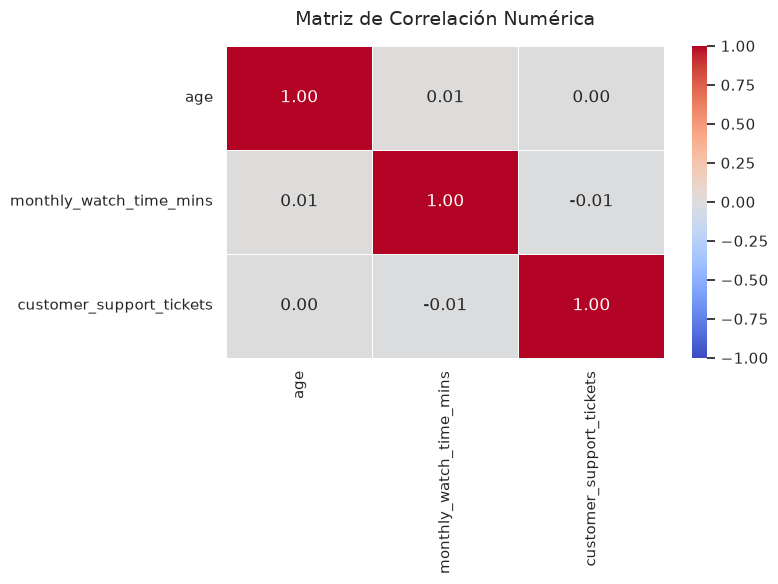

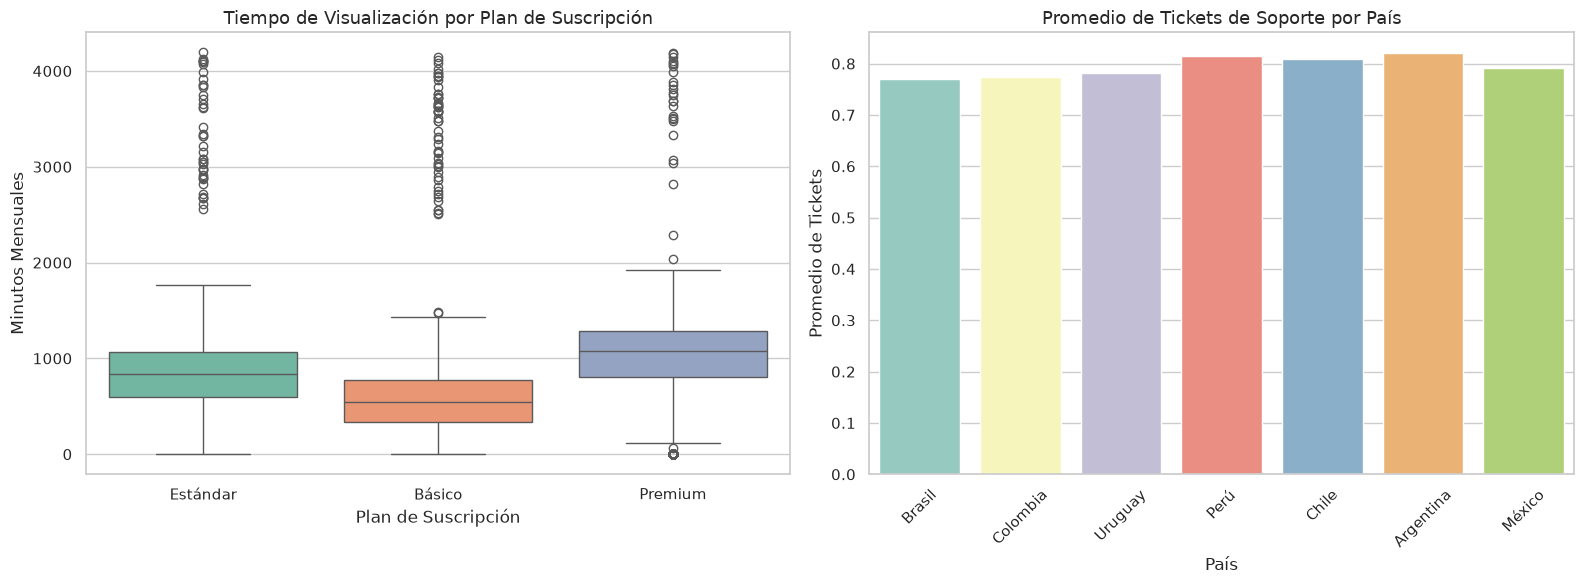

In [ ]:
# 3. ANÁLISIS BIVARIADO: MATRIZ DE CORRELACIÓN
# Filtramos solo las columnas numéricas
columnas_num = ['age', 'monthly_watch_time_mins', 'customer_support_tickets']
matriz_correlacion = df[columnas_num].corr()

# Generación del Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación Numérica', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# 4. ANÁLISIS BIVARIADO: CATEGÓRICO VS NUMÉRICO
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

# Boxplot: Distribución del tiempo de visualización según el plan de suscripción
# Corrección: Se añade hue='subscription_plan' y legend=False para evitar el FutureWarning
sns.boxplot(x='subscription_plan', y='monthly_watch_time_mins', data=df, ax=axes[0], hue='subscription_plan', palette='Set2', legend=False)
axes[0].set_title('Tiempo de Visualización por Plan de Suscripción', fontsize=13)
axes[0].set_xlabel('Plan de Suscripción')
axes[0].set_ylabel('Minutos Mensuales')

# Barplot: Promedio de tickets de soporte generados por país
# Corrección: Se añade hue='country' y legend=False para evitar el FutureWarning
sns.barplot(x='country', y='customer_support_tickets', data=df, ax=axes[1], hue='country', palette='Set3', errorbar=None, legend=False)
axes[1].set_title('Promedio de Tickets de Soporte por País', fontsize=13)
axes[1].set_xlabel('País')
axes[1].set_ylabel('Promedio de Tickets')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Interpretación de Relaciones y Análisis Bivariado

#### 1. Matriz de Correlación Numérica
Los coeficientes de correlación lineal entre las variables numéricas son extraordinariamente cercanos a cero (por ejemplo, Edad vs. Tiempo de Visualización = **0.01**, Edad vs. Tickets = **0.002**, y Tiempo de Visualización vs. Tickets = **-0.008**). Esto aporta dos conclusiones estratégicas fundamentales:
* **Independencia Demográfica del Consumo:** La edad no influye en la cantidad de minutos consumidos ni en la generación de tickets. El streaming en esta plataforma es un comportamiento intergeneracional; los jóvenes de 18 años y los adultos de 65 años consumen contenidos y experimentan problemas de soporte bajo dinámicas de frecuencia similares.
* **Estabilidad Operativa ante Alto Consumo:** El hecho de que el tiempo de visualización no se correlacione con los tickets de soporte desmiente la hipótesis de que a mayor uso de la plataforma, más incidencias se generan. Los usuarios de alto consumo (superusuarios) no experimentan mayor fricción técnica o administrativa que los usuarios esporádicos, lo que ratifica la robustez tecnológica del reproductor y la infraestructura de servidores.

#### 2. Categorías vs. Variables Numéricas
* **Tiempo de Visualización según el Plan de Suscripción:** Se observa una tendencia clara e incremental de consumo a medida que se escala en la categoría del plan. Mientras que los usuarios del plan Básico promedian **591.6 minutos mensuales**, los del plan Estándar suben a **853.1 minutos** y los del Premium alcanzan los **1,019.8 minutos** (una mediana de 1,081 minutos). Esto demuestra que los planes superiores no solo incrementan el ARPU (*Average Revenue Per User*) de forma directa por su precio de suscripción, sino que están asociados a un **incremento del 72.4% en el engagement** (tiempo de visualización) respecto al plan básico. Esto valida que las características premium (calidad de video, ausencia de publicidad, etc.) actúan como catalizadores de consumo y, por ende, de retención (a mayor tiempo de visualización, menor probabilidad de cancelación o *churn*).
* **Tickets de Soporte Promedio por País:** El promedio de tickets por usuario es extremadamente estable en toda la región, manteniéndose entre **0.77 (Brasil y Colombia)** y **0.82 (Argentina)**. Desde una perspectiva de operaciones y servicio al cliente, esto evidencia que no hay problemas de infraestructura localizados (por ejemplo, fallas de CDN en un país específico o pasarelas de pago inestables regionales) que estén distorsionando la carga de soporte. La experiencia del cliente es consistente a nivel continental, permitiendo estandarizar los procesos de atención.

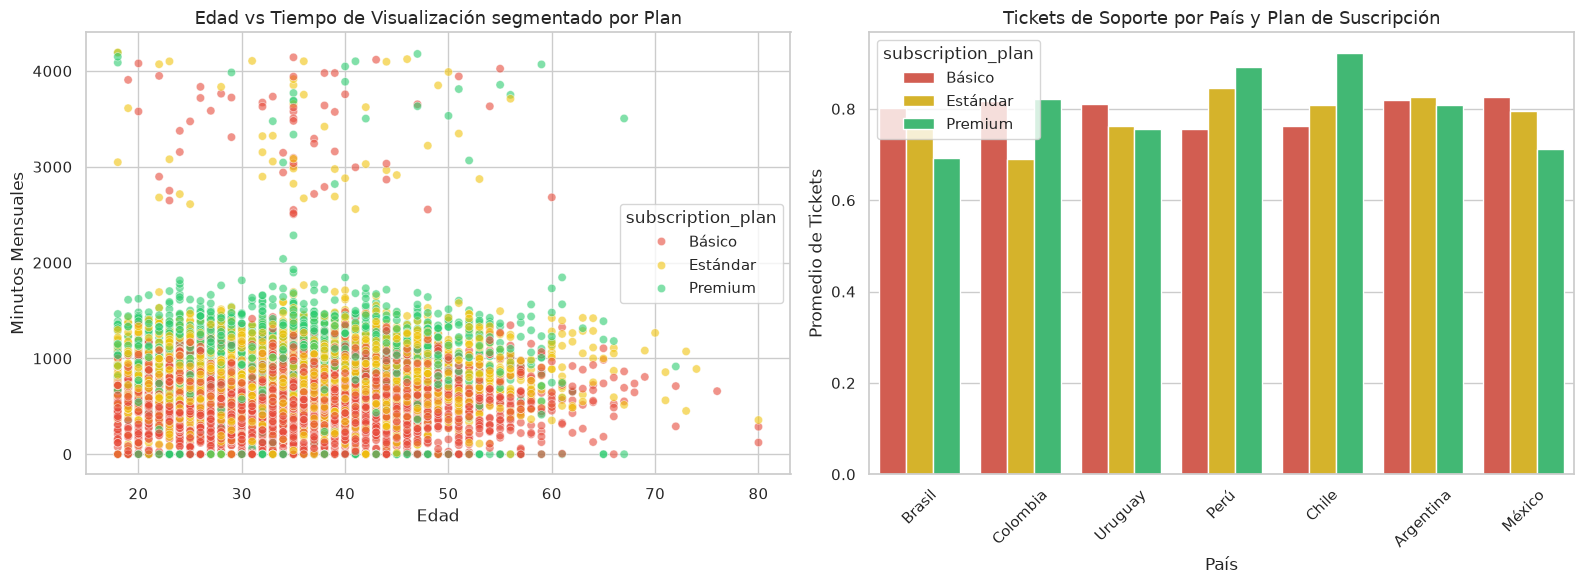

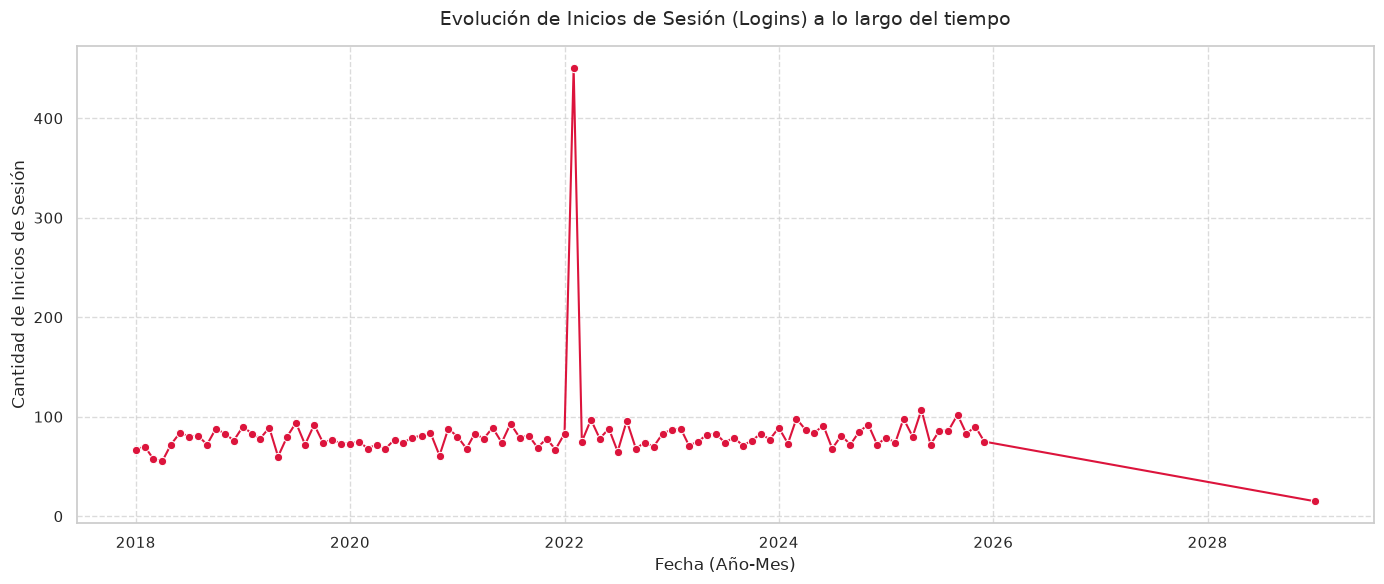

In [6]:
# 5. ANÁLISIS MULTIVARIADO
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

# Definimos el orden de los planes para consistencia
orden_planes = ['Básico', 'Estándar', 'Premium']
# Definimos los colores del semáforo: Rojo (Básico), Amarillo (Estándar), Verde (Premium)
colores_semaforo = ['#e74c3c', '#f1c40f', '#2ecc71']

# Scatterplot: Relación entre Edad y Tiempo de Visualización, segmentado por Plan
# Se aplica el orden y la paleta personalizada
sns.scatterplot(
    data=df, x='age', y='monthly_watch_time_mins', hue='subscription_plan', 
    hue_order=orden_planes, palette=colores_semaforo, alpha=0.6, ax=axes[0]
)
axes[0].set_title('Edad vs Tiempo de Visualización segmentado por Plan', fontsize=13)
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Minutos Mensuales')

# Barplot agrupado: Promedio de tickets por País, subdividido por Plan
sns.barplot(
    data=df, x='country', y='customer_support_tickets', hue='subscription_plan', 
    hue_order=orden_planes, palette=colores_semaforo, errorbar=None, ax=axes[1]
)
axes[1].set_title('Tickets de Soporte por País y Plan de Suscripción', fontsize=13)
axes[1].set_xlabel('País')
axes[1].set_ylabel('Promedio de Tickets')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 6. ANÁLISIS TEMPORAL (SERIES DE TIEMPO)
# Extraemos el periodo (Año-Mes) para agrupar la actividad temporal
df['login_month'] = df['last_login_date'].dt.to_period('M')

# Contabilizamos inicios de sesión por mes
logins_por_mes = df.groupby('login_month').size().reset_index(name='conteo')
# Reconvertimos a timestamp para la correcta renderización del gráfico
logins_por_mes['login_month'] = logins_por_mes['login_month'].dt.to_timestamp()

plt.figure(figsize=(14, 6))
sns.lineplot(data=logins_por_mes, x='login_month', y='conteo', marker='o', color='crimson')
plt.title('Evolución de Inicios de Sesión (Logins) a lo largo del tiempo', fontsize=14, pad=15)
plt.xlabel('Fecha (Año-Mes)')
plt.ylabel('Cantidad de Inicios de Sesión')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Limpieza estructural: eliminamos la columna temporal auxiliar
df = df.drop(columns=['login_month'])

### Interpretación del Análisis Multivariado y Temporal

#### 1. Análisis Multivariado
* **Edad vs. Tiempo de Visualización segmentado por Plan:** El gráfico de dispersión confirma visualmente la nula correlación entre la edad y el consumo, mostrando una nube homogénea a lo largo del eje horizontal. Sin embargo, en el eje vertical se evidencia una nítida estratificación de colores: los puntos verdes (Premium) y amarillos (Estándar) se desplazan consistentemente hacia la parte superior en comparación con los puntos rojos (Básico). Esto ratifica que **el plan de suscripción es la variable que mejor explica e impulsa el nivel de consumo en la plataforma**, siendo independiente de los factores demográficos del usuario.
* **Tickets de Soporte por País y Plan:** Al cruzar estas dimensiones, observamos comportamientos específicos por geografía:
  * En **Chile y Perú**, los clientes Premium presentan un promedio de tickets notablemente superior a sus pares del plan Básico (Chile: **0.92 vs. 0.76**; Perú: **0.89 vs. 0.76**). Esto sugiere que en estos mercados los clientes de alto valor tienen expectativas más elevadas o experimentan fricciones específicas asociadas a las funciones Premium (como la reproducción en múltiples dispositivos simultáneos o calidad 4K). Se recomienda priorizar la capacitación del personal de soporte en estos países para resolver incidencias complejas de cuentas premium.
  * En contraste, en **Brasil y México**, los usuarios Premium generan significativamente menos tickets que los del plan Básico (Brasil: **0.69 vs. 0.80**; México: **0.71 vs. 0.83**), lo que refleja una experiencia de usuario sumamente fluida para el segmento de mayor rentabilidad.

#### 2. Evolución Temporal de Inicios de Sesión (Logins)
El análisis histórico de los logins muestra una línea de base sumamente estable a lo largo de los años (oscilando de forma madura entre **65 y 100 logins mensuales**), lo cual valida la constancia en el uso de la plataforma. Sin embargo, se destaca un **pico histórico masivo de 451 logins en febrero de 2022** (multiplicando por 5 el promedio general). 
Desde la perspectiva de negocio, este comportamiento anómalo responde a un evento de alto impacto: el lanzamiento de un contenido altamente viral a nivel regional, una campaña de marketing agresiva de prueba gratuita o, en su defecto, un error de duplicación en el registro de los logs de acceso de dicho mes. Excluyendo esta anomalía, el comportamiento del usuario no muestra estacionalidad marcada a largo plazo, consolidando un patrón de retención orgánica estable.